In [1]:
import os
os.environ['LD_LIBRARY_PATH'] = '/usr/local/cuda/lib64:' + os.environ.get('LD_LIBRARY_PATH', '')


In [2]:
import os
print("LD_LIBRARY_PATH:", os.environ.get('LD_LIBRARY_PATH'))


LD_LIBRARY_PATH: /usr/local/cuda/lib64:


In [3]:
import tensorflow as tf
print("GPUs detected:", tf.config.list_physical_devices('GPU'))


2025-06-23 14:59:13.082058: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-23 14:59:13.300716: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750708753.371922     669 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750708753.392976     669 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750708753.551760     669 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


loading Roboflow workspace...
loading Roboflow project...


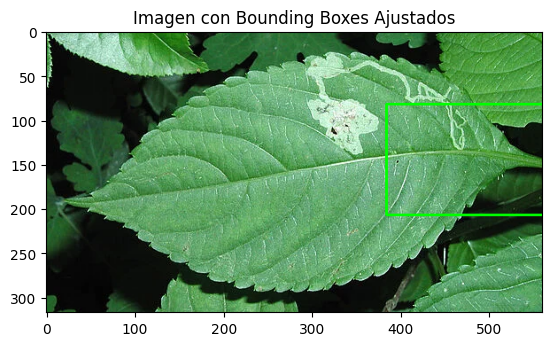

In [12]:
from roboflow import Roboflow
import cv2
import matplotlib.pyplot as plt

# Usar tu clave de API de Roboflow
rf = Roboflow(api_key="H5Uc16sKkVGtvQ5aIrFQ")

# Cargar el proyecto y modelo
project = rf.workspace().project("liriomyza-huidobrensis")
model = project.version(2).model

# Realizar la inferencia
image_path = "../Huevo/plaga.jpg"
result = model.predict(image_path, confidence=30, overlap=50).json()

# Cargar la imagen original para obtener las dimensiones
image = cv2.imread(image_path)

# Obtener las dimensiones originales de la imagen
original_height, original_width, _ = image.shape

# Definir el nuevo tamaño de la imagen (640x640 para este modelo)
new_width, new_height = 640, 640

# Función para ajustar las coordenadas de los cuadros delimitadores
def adjust_bboxes(predictions, original_width, original_height, new_width, new_height):
    adjusted_predictions = []
    for pred in predictions:
        x = pred['x'] * new_width / original_width
        y = pred['y'] * new_height / original_height
        w = pred['width'] * new_width / original_width
        h = pred['height'] * new_height / original_height
        adjusted_predictions.append({
            'x': x,
            'y': y,
            'width': w,
            'height': h,
            'confidence': pred['confidence'],
            'class': pred['class']
        })
    return adjusted_predictions

# Ajustar las predicciones al tamaño redimensionado
adjusted_predictions = adjust_bboxes(result['predictions'], original_width, original_height, new_width, new_height)

# Dibujar los cuadros delimitadores ajustados sobre la imagen
for prediction in adjusted_predictions:
    x, y, w, h = prediction['x'], prediction['y'], prediction['width'], prediction['height']
    cv2.rectangle(image, (int(x), int(y)), (int(x + w), int(y + h)), (0, 255, 0), 2)

# Mostrar la imagen con las cajas delimitadoras
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Imagen con Bounding Boxes Ajustados')
plt.show()


In [ ]:
! pip install 'inference[transformers]'

ModelDependencyMissing: Your `inference` configuration does not support PaliGemma model. Use pip install 'inference[transformers]' to install missing requirements.
ModelDependencyMissing: Your `inference` configuration does not support Florence2 model. Use pip install 'inference[transformers]' to install missing requirements.
ModelDependencyMissing: Your `inference` configuration does not support Qwen2.5-VL model. Use pip install 'inference[transformers]' to install missing requirements.
ModelDependencyMissing: Your `inference` configuration does not support SAM model. Use pip install 'inference[sam]' to install missing requirements.
ModelDependencyMissing: Your `inference` configuration does not support SAM model. Use pip install 'inference[sam]' to install missing requirements.
ModelDependencyMissing: Your `inference` configuration does not support SAM model. Use pip install 'inference[clip]' to install missing requirements.
ModelDependencyMissing: Your `inference` configuration does

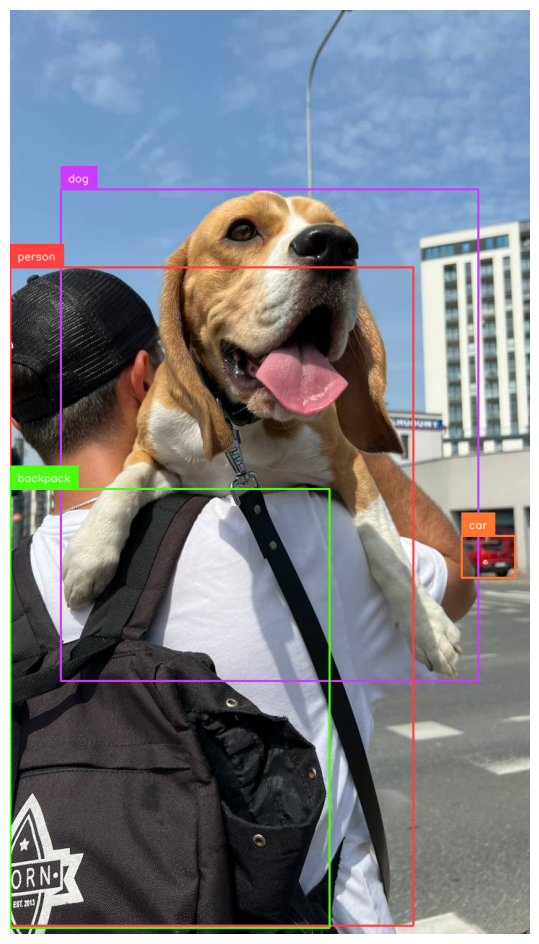

KeyboardInterrupt: 

In [15]:
import os
import supervision as sv
from inference import get_model
from PIL import Image
from io import BytesIO
import requests

response = requests.get("https://media.roboflow.com/dog.jpeg")

if response.status_code == 200:
    image_data = BytesIO(response.content)

    image = Image.open(image_data)

model = get_model("rfdetr-base")

predictions = model.infer(image, confidence=0.5)[0]

detections = sv.Detections.from_inference(predictions)

labels = [prediction.class_name for prediction in predictions.predictions]

annotated_image = image.copy()
annotated_image = sv.BoxAnnotator().annotate(annotated_image, detections)
annotated_image = sv.LabelAnnotator().annotate(annotated_image, detections, labels)

sv.plot_image(annotated_image)

annotated_image.save("annotated_image_base.jpg")

model = get_model("rfdetr-large")

predictions = model.infer(image, confidence=0.5)[0]

detections = sv.Detections.from_inference(predictions)

labels = [prediction.class_name for prediction in predictions.predictions]

annotated_image = image.copy()
annotated_image = sv.BoxAnnotator().annotate(annotated_image, detections)
annotated_image = sv.LabelAnnotator().annotate(annotated_image, detections, labels)

sv.plot_image(annotated_image)

annotated_image.save("annotated_image_large.jpg")

Predicciones encontradas:
Predicción 1: {'width': 280.2113723754883, 'height': 203.828125, 'x': 241.56292343139648, 'y': 179.5916748046875, 'confidence': 0.798332929611206, 'class_id': 0, 'class': 'leaf-liriomyza', 'detection_id': 'a7ab3ce0-42ef-49c5-8b0e-d4fb16062dba', 'parent_id': 'image'}
Dibujando caja: centro=(241.56292343139648, 179.5916748046875), tamaño=(280.2113723754883x203.828125)
Coordenadas finales: (101, 77) a (381, 281)


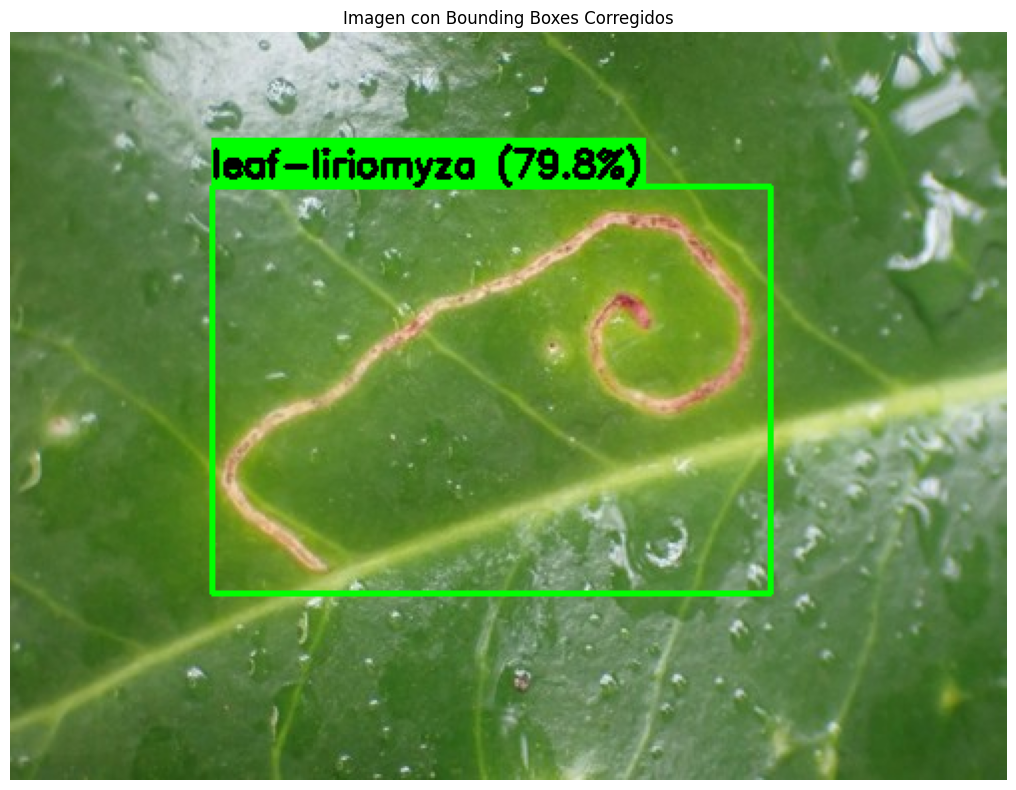

In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from inference_sdk import InferenceHTTPClient

# Inicializar el cliente de inferencia
client = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key="H5Uc16sKkVGtvQ5aIrFQ"
)

# Ruta a la imagen local
path_image = '../Modelo_3/data_3/liriomyza/image_36.jpeg'  # Cambia esto con la ruta correcta de tu imagen

# Ejecutar la inferencia en el flujo de trabajo
result = client.run_workflow(
    workspace_name="dl-w5fkx",
    workflow_id="detect-and-classify",
    images={
        "image": path_image
    },
    use_cache=True
)

# Ver el resultado
first_result = result[0]
detection_predictions = first_result["detection_predictions"]
predictions = detection_predictions["predictions"]

# Imprimir las predicciones para verificar su estructura
print("Predicciones encontradas:")
for i, pred in enumerate(predictions):
    print(f"Predicción {i+1}: {pred}")

# Cargar la imagen original
image = cv2.imread(path_image)
if image is None:
    print(f"Error: No se pudo cargar la imagen desde {path_image}")
    exit()

# Hacer una copia para dibujar
image_with_boxes = image.copy()

# Procesar las predicciones
for prediction in predictions:
    # Las coordenadas vienen como centro (x, y) con ancho y alto
    center_x = prediction['x']
    center_y = prediction['y']
    width = prediction['width']
    height = prediction['height']
    confidence = prediction['confidence']
    label = prediction['class']
    
    # Convertir de coordenadas de centro a coordenadas de esquina superior izquierda
    x1 = int(center_x - width / 2)
    y1 = int(center_y - height / 2)
    x2 = int(center_x + width / 2)
    y2 = int(center_y + height / 2)
    
    print(f"Dibujando caja: centro=({center_x}, {center_y}), tamaño=({width}x{height})")
    print(f"Coordenadas finales: ({x1}, {y1}) a ({x2}, {y2})")
    
    # Dibujar el cuadro delimitador sobre la imagen
    cv2.rectangle(image_with_boxes, (x1, y1), (x2, y2), (0, 255, 0), 2)  # Verde, grosor 2
    
    # Añadir etiqueta con confianza
    label_text = f"{label} ({confidence*100:.1f}%)"
    
    # Obtener el tamaño del texto para el fondo
    (text_width, text_height), baseline = cv2.getTextSize(
        label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2
    )
    
    # Dibujar fondo para el texto
    cv2.rectangle(image_with_boxes, 
                  (x1, y1 - text_height - 10), 
                  (x1 + text_width, y1), 
                  (0, 255, 0), -1)
    
    # Dibujar el texto
    cv2.putText(image_with_boxes, label_text, (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

# Mostrar la imagen con las cajas delimitadoras
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(image_with_boxes, cv2.COLOR_BGR2RGB))
plt.title('Imagen con Bounding Boxes Corregidos')
plt.axis('off')
plt.tight_layout()
plt.show()



In [ ]:
from roboflow import Roboflow
import supervision as sv
import cv2

rf = Roboflow(api_key="H5Uc16sKkVGtvQ5aIrFQ")
project = rf.workspace().project("minador-de-hojas-02lwo")
model = project.version(2).model

result = model.predict("../Huevo/danios-de-minadores (1).jpg", confidence=40, overlap=30).json()

labels = [item["class"] for item in result["predictions"]]

detections = sv.Detections.from_roboflow(result)

label_annotator = sv.LabelAnnotator()
bounding_box_annotator = sv.BoxAnnotator()

image = cv2.imread("../Huevo/danios-de-minadores (1).jpg")

annotated_image = bounding_box_annotator.annotate(
    scene=image, detections=detections)
annotated_image = label_annotator.annotate(
    scene=annotated_image, detections=detections, labels=labels)

sv.plot_image(image=annotated_image, size=(16, 16))

loading Roboflow workspace...
loading Roboflow project...


AttributeError: type object 'Detections' has no attribute 'from_roboflow'